In [19]:
import os
import sys

In [20]:
# Add the project root to Python path so we can import prostate_cancer module
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [21]:
import logging

import hydra
import numpy as np
import torch
from lightning import seed_everything
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score

from prostate_cancer.data import DataModule
from prostate_cancer.prostate_cancer_model import ProstateCancerModel

In [22]:
logging.basicConfig(level=logging.INFO)

# Set random seed for reproducibility
seed_everything(42, workers=True)
torch.set_float32_matmul_precision(precision="medium")

Seed set to 42


In [2]:
# Configuration overrides for prediction
overrides = ["experiment=predict/images/vgg16", "mode=predict"]

# Initialize Hydra configuration
with hydra.initialize(config_path="../configs", version_base=None):
    config = hydra.compose(config_name="default", overrides=overrides)

print("Configuration loaded successfully!")
print(f"Mode: {config.mode}")
print(f"Checkpoint: {config.checkpoint}")
print(f"Batch size: {config.data.batch_size}")

Configuration loaded successfully!
Mode: predict
Checkpoint: mlflow-artifacts:/65/7b52930515c14710855962f8882fb4d3/artifacts/checkpoints/epoch=1-step=11620/checkpoint.ckpt
Batch size: 74


In [3]:
# Instantiate data module and model
data: DataModule = hydra.utils.instantiate(
    config.data,
    _recursive_=False,  # to avoid instantiating all the datasets
    _target_=DataModule,
)

model: ProstateCancerModel = hydra.utils.instantiate(config.model)

print("Data module and model instantiated successfully!")
print(f"Model type: {type(model)}")
print(f"Data module type: {type(data)}")

Data module and model instantiated successfully!
Model type: <class 'prostate_cancer.prostate_cancer_model.ProstateCancerModel'>
Data module type: <class 'prostate_cancer.data.data_module.DataModule'>


In [4]:
model.eval()

ProstateCancerModel(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, paddi

In [5]:
# Get one batch from validation dataset
data.batch_size = 1
data.setup("val")

/home/jovyan/prostate-cancer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovyan/prostate-cancer/.venv/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.6'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [6]:
dataloader = data.val_dataloader()
print(type(data.val_dataloader()))

<class 'torch.utils.data.dataloader.DataLoader'>


In [7]:
x, labels, metadata = batch = next(iter(dataloader))

In [8]:
print(x.shape)
print(labels.shape)
print(len(metadata))

torch.Size([1, 3, 512, 512])
torch.Size([1, 1])
3


In [9]:
def batch_to_images(batch_tensor, mean=None, std=None):
    """Convert a batch tensor to a list of denormalized images.

    Args:
        batch_tensor: PyTorch tensor of shape [B, C, H, W]
        mean: Normalization mean values [C] (if None, uses default values)
        std: Normalization std values [C] (if None, uses default values)

    Returns:
        List of numpy arrays, each of shape [H, W, C] with uint8 values
    """
    import numpy as np

    # Use default normalization values if not provided
    if mean is None:
        mean = np.array([228.5544, 178.8584, 219.8793])
    if std is None:
        std = np.array([27.8285, 51.4639, 26.4458])

    # Convert to numpy and move to CPU if needed
    batch_np = batch_tensor.cpu().numpy()

    # Process each image in the batch
    images = []
    for i in range(batch_np.shape[0]):
        # Get single image: [C, H, W]
        image = batch_np[i]

        # Transpose from CHW to HWC
        image_hwc = image.transpose(1, 2, 0)

        # Denormalize: (normalized * std) + mean
        image_denorm = (image_hwc * std) + mean

        # Clip to valid pixel range and convert to uint8
        image_denorm = np.clip(image_denorm, 0, 255).astype(np.uint8)

        images.append(Image.fromarray(image_denorm))

    return images

In [10]:
def plot_batch(x):
    for i in batch_to_images(x):
        display(i)

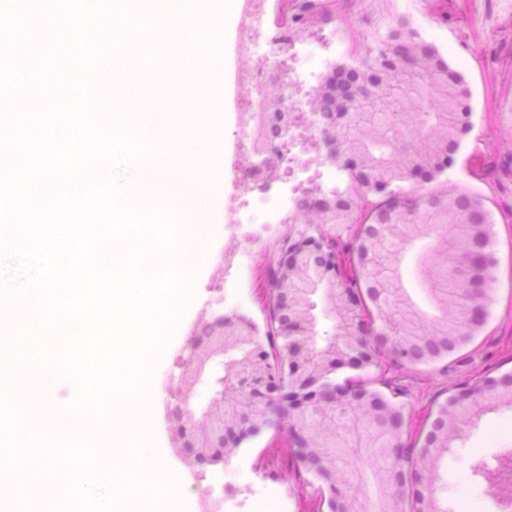

In [11]:
plot_batch(x)

In [12]:
y = model.predict_step((x, labels), 0, 0)

In [13]:
print(f"prediction: {y}, label: {labels[0]}")

prediction: tensor([[0.0060]], grad_fn=<SigmoidBackward0>), label: tensor([1.])


In [14]:
# Get one batch from validation dataset
data.batch_size = 200
dataloader_larger = data.val_dataloader()

In [15]:
batch = next(iter(dataloader_larger))
x, labels, metadata = batch

In [16]:
print(x.shape)

torch.Size([200, 3, 512, 512])


In [17]:
with torch.no_grad():
    predictions = model.predict_step((x, metadata), 0, 0)

In [18]:
# Convert to numpy
all_predictions = np.array(predictions > 0.5)

# count 1, and 0
print(np.sum(all_predictions == 1))
print(np.sum(all_predictions == 0))

all_labels = np.array(labels)

# count 1, and 0
print(np.sum(all_labels == 1))
print(np.sum(all_labels == 0))

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

/tmp/ipykernel_485/1258370115.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_predictions = np.array(predictions > 0.5)
/tmp/ipykernel_485/1258370115.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_labels = np.array(labels)


0
200
200
0
Accuracy: 0.0
Precision: 0.0
Recall: 0.0


/home/jovyan/prostate-cancer/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
